# **Helper Functions**

## Importing Dependencies

In [1]:
import time
import numpy as np
import os
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torchsummary

import seaborn
from sklearn.metrics import confusion_matrix

## Constants

In [2]:
SEED = 42
BATCH_SIZE = 128
CLASS_LABELS = ["airplaine", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

## Preprocessing Images and Creating Split

In [3]:
def set_seed(seed: int = SEED) -> None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def get_split(batch: int = BATCH_SIZE, workers: int=2, path: str = "./data"):
    """
    Returns a CIFAR10 train/val/test split as required using a set seed of 42 to ensure a consistent split of images throughout each run
    """

    # Required to normalize the images
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    # Defining the two transform sets that will be used on the dataset
    tf_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    tf_valTest = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    # Bifurcating transforms for each split
    ds_aug = torchvision.datasets.CIFAR10(path, train=True, download=True, transform=tf_train)
    ds_norm = torchvision.datasets.CIFAR10(path, train=True, download=False, transform=tf_valTest)
    ds_test = torchvision.datasets.CIFAR10(path, train=False, download=False, transform=tf_valTest)

    # Creating the split
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(50_000)
    tr_id = perm[:45_000] # Training Split = 45k images
    val_id = perm[45_000:] # Valudation Split = 5k images

    kw = dict(num_workers=workers, pin_memory=torch.cuda.is_available())

    train_split = DataLoader(Subset(ds_aug, tr_id), batch_size=batch, shuffle=True, **kw)
    val_split = DataLoader(Subset(ds_norm, val_id), batch_size=batch, shuffle=False, **kw)
    test_split = DataLoader(ds_test, batch_size=batch, shuffle=False, **kw)

    print(f"Data   : {len(tr_id):,} train | {len(val_id):,} val | {len(ds_test):,} test")

    return train_split, val_split, test_split

## Parameter Counting

In [4]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_hyperparams(**kwargs) -> None:
    print("\n" + "─" * 50)
    for k, v in kwargs.items():
        print(f"  {k:<18}: {v}")
    print("─" * 50)

## Training-Related Functions

In [ ]:
def _train_epoch(model, loader, crit, opt, device):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = crit(model(x), y)
        loss.backward()
        opt.step()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def _eval_epoch(model, loader, crit, device):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    all_pred, all_true = [], []
    for x, y in loader:
        x, y    = x.to(device), y.to(device)
        out     = model(x)
        loss_sum += crit(out, y).item() * x.size(0)
        pred    = out.argmax(1)
        correct += pred.eq(y).sum().item()
        n       += y.size(0)
        all_pred.extend(pred.cpu().numpy())
        all_true.extend(y.cpu().numpy())
    return (loss_sum / n,
            100.0 * correct / n,
            np.array(all_pred),
            np.array(all_true))

def train_model(model, train_split, val_split,
                num_epochs, optimizer, scheduler=None, device=None):
    """
    Full training loop.  Returns a history dict with keys:
      train_loss, val_loss, val_acc, epoch_time
    """
    if device is None:
        device = "cuda:0"
    model.to(device)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}

    for ep in range(num_epochs):
        t0      = time.time()
        tr_loss = _train_epoch(model, train_split, crit, optimizer, device)
        vl_loss, vl_acc, _, _ = _eval_epoch(model, val_split, crit, device)
        dt      = time.time() - t0
        if scheduler:
            scheduler.step()

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(vl_loss)
        hist["val_acc"].append(vl_acc)
        hist["epoch_time"].append(dt)

        print(f"  Ep {ep+1:3d}/{num_epochs}  "
              f"TrLoss {tr_loss:.4f}  VlLoss {vl_loss:.4f}  "
              f"VlAcc {vl_acc:6.2f}%  ({dt:.1f}s)")

    return hist


@torch.no_grad()
def evaluate(model, loader, device):
    """Final evaluation on any loader — returns (loss, acc, preds, labels)."""
    model.to(device)
    return _eval_epoch(model, loader, nn.CrossEntropyLoss(), device)

## Graphing Functions

In [8]:
def save_training_curves(histories: dict, title: str, path: str) -> None:
    """
    histories: {label: history_dict}
    Produces a 3-panel figure: Training Loss | Validation Loss | Validation Accuracy
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    panels = [("train_loss", "Training Loss",     "Loss"),
              ("val_loss",   "Validation Loss",   "Loss"),
              ("val_acc",    "Validation Accuracy","Accuracy (%)")]

    for lbl, h in histories.items():
        for ax, (key, ttl, yl) in zip(axes, panels):
            ax.plot(h[key], label=lbl, linewidth=1.5)

    for ax, (_, ttl, yl) in zip(axes, panels):
        ax.set(title=ttl, xlabel="Epoch", ylabel=yl)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {path}")

def _cm(true, pred):
    return confusion_matrix(true, pred)

def save_confusion_matrix(true_labels, pred_labels, title: str, path: str) -> None:
    cm = _cm(true_labels, pred_labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    seaborn.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
                    linewidths=0.4, ax=ax)
    
    ax.set(title=title, xlabel="Predicted Label", ylabel="True Label")
    plt.tight_layout()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {path}")

def save_filter_visualization(model: nn.Module, title: str, path: str) -> None:
    """
    Visualises the learned filters of the first Conv2d layer.
    Filters with 3 input channels are shown as RGB patches;
    single-channel filters are shown with a 'viridis' colourmap.
    """
    first_conv = next(m for m in model.modules() if isinstance(m, nn.Conv2d))
    W = first_conv.weight.detach().cpu()          # [C_out, C_in, H, W]
    n = min(W.shape[0], 64)
    ncols = 8
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.5, nrows * 1.5))
    axes = np.array(axes).reshape(nrows, ncols)

    for i in range(nrows * ncols):
        ax = axes[i // ncols, i % ncols]
        if i < n:
            w = W[i]                              # [C_in, H, W]
            w = w - w.min()
            w = w / (w.max() + 1e-8)             # normalise to [0, 1]
            if w.shape[0] == 3:
                ax.imshow(w.permute(1, 2, 0).numpy())
            else:
                ax.imshow(w[0].numpy(), cmap="viridis")
        ax.axis("off")

    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {path}")

# For Question 3
def save_results(out_dir: str, data: dict) -> None:
    os.makedirs(out_dir, exist_ok=True)
    p = os.path.join(out_dir, "results.json")
    with open(p, "w") as f:
        json.dump(data, f, indent=2)
    print(f"  Saved → {p}")

def load_results(out_dir: str) -> dict:
    p = os.path.join(out_dir, "results.json")
    if not os.path.exists(p):
        return {}
    with open(p) as f:
        return json.load(f)

# **Question 2**

## Set-Up

In [9]:
# Configuring hyperparameters
learning_rate = 1e-3
weight_decay = 1e-4
NUM_EPOCHS = 40

out_path = "output/q2"
os.makedirs(out_path, exist_ok=True)

class CIFAR10VGG11(nn.Module):
    # Original VGG-11 cfg:
    # [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']
    cifar10_cfg = [16, 'M', 32, 'M', 64, 64, 'M', 128, 128, 'M', 128, 128, 'M']

    def __init__(self, num_classes: int=10, dropout_rate: float=0.0):
        super().__init__()

        layers = []
        input_channel = 3
        for v in self.cifar10_cfg:
            if v == 'M':
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            else:
                layers += [
                    nn.Conv2d(input_channel, v, kernel_size=3, padding=1),
                    nn.ReLU(inplace=True),
                ]
                input_channel = v

        self.features = nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.Linear(128 * 1 * 1, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, num_classes),
        )
 
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

def make_opt_sched(model):
    opt   = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    return opt, sched

def convergence_epoch(val_acc_list, threshold=0.80):
    """
    Returns the first epoch at which val accuracy reaches `threshold`
    fraction of its final value.  Used for the required comparison study.
    """
    target = threshold * val_acc_list[-1]
    for i, acc in enumerate(val_acc_list):
        if acc >= target:
            return i + 1
    return len(val_acc_list)

## **Part 2A**

In [ ]:
def part_a(train_split, val_split, test_split, device, p1_results: dict):
    print("\n" + "=" * 60)
    print("Question 2: Part A")
    print("=" * 60)

    # Architecture
    set_seed(SEED)
    model  = CIFAR10VGG11(dropout_rate=0.0)
    params = count_parameters(model)

    print(f"\nCIFAR10 VGG-11 params  : {params:>12,}")
    if p1_results:
        print(f"Modified AlexNet params: {p1_results['params']:>12,}")
        print(f"Difference             : {abs(params - p1_results['params']):>12,}")

    # Layer-wise breakdown
    print("\nLayer-wise parameter breakdown:")
    for name, p in model.named_parameters():
        print(f"  {name:<45} {p.numel():>10,}")
    print(f"  {'TOTAL':<45} {params:>10,}")

    # Printing Hyper Params
    print_hyperparams(
        Problem="2A",
        Model="CIFAR10VGG11 (p=0.0)",
        Epochs=NUM_EPOCHS,
        BatchSize=BATCH_SIZE,
        Optimizer=f"Adam lr={learning_rate} wd={weight_decay}",
        Scheduler=f"CosineAnnealingLR T_max={NUM_EPOCHS}",
        Device=device,
        Seed=SEED,
    )

    opt, sched = make_opt_sched(model)
    history = train_model(model, train_split, val_split,
                          NUM_EPOCHS, opt, sched, device)

    # Final Test Eval
    _, test_acc, preds, labels = evaluate(model, test_split, device)
    print(f"\nFinal Test Accuracy : {test_acc:.2f}%")

    # Training Curves
    save_training_curves(
        {"VGG-11 Baseline (no dropout)": history},
        "Adapted VGG-11 Training Curves: Part A",
        f"{out_path}/2a_training_curves.png",
    )

    save_confusion_matrix(
        labels, preds,
        f"Adapted VGG-11 — Confusion Matrix  (Test Acc: {test_acc:.2f}%)",
        f"{out_path}/2a_confusion_matrix.png",
    )

    # Comparison Table b/w AlexNet and VGG11
    avg_time_vgg  = sum(history["epoch_time"]) / len(history["epoch_time"])
    conv_vgg      = convergence_epoch(history["val_acc"])

    print("\nAlexNet vs VGG-11 Comparison")
    if p1_results:
        avg_time_alex = p1_results.get("avg_epoch_time", "N/A")
        conv_alex     = p1_results.get("convergence_epoch", "N/A")
        alex_acc      = p1_results.get("baseline_acc", "N/A")
        alex_params   = p1_results.get("params", "N/A")

        print(f"  {'Metric':<35} {'AlexNet':>12} {'VGG-11':>12}")
        print(f"  {'─'*60}")
        print(f"  {'Parameters':35} {alex_params:>12,} {params:>12,}")
        print(f"  {'Test Accuracy (%)':35} {alex_acc:>12.2f} {test_acc:>12.2f}")
        if isinstance(avg_time_alex, float):
            print(f"  {'Avg Epoch Time (s)':35} {avg_time_alex:>12.1f} {avg_time_vgg:>12.1f}")
        if isinstance(conv_alex, int):
            print(f"  {'Epoch to 80% of final val acc':35} {conv_alex:>12} {conv_vgg:>12}")
    else:
        print("  (Run problem1_alexnet.py first to generate comparison numbers)")

    return model, history, test_acc, params, avg_time_vgg, conv_vgg

# **Part 2B**

In [ ]:
def part_b(baseline_history, baseline_test_acc,
               train_split, val_split, test_split, device,
               p1_results: dict):
    print("\n" + "=" * 60)
    print("Question 2: Part B")
    print("=" * 60)

    histories  = {"VGG-11 Baseline (p=0.0)": baseline_history}
    vgg_results = {"p=0.0": baseline_test_acc}

    for p in [0.3, 0.5]:
        print(f"\nVGG-11 Dropout rate p = {p}")
        set_seed(SEED)
        model = CIFAR10VGG11(dropout_rate=p)
        opt, sched = make_opt_sched(model)
        history = train_model(model, train_split, val_split,
                              NUM_EPOCHS, opt, sched, device)

        _, test_acc, preds, labels = evaluate(model, test_split, device)
        print(f"Test Accuracy (VGG-11, p={p}): {test_acc:.2f}%")

        tag = f"VGG-11 p={p}"
        histories[tag] = history
        vgg_results[f"p={p}"] = test_acc

        save_confusion_matrix(
            labels, preds,
            f"CIFAR10 VGG-11 (dropout p={p}): Confusion Matrix  (Test Acc: {test_acc:.2f}%)",
            f"{out_path}/2b_cm_p{'03' if p == 0.3 else '05'}.png",
        )

    # Comparison Grpahs
    save_training_curves(
        histories,
        "CIFAR10 VGG-11 Dropout Comparison: Part B",
        f"{out_path}/2b_dropout_comparison.png",
    )

    # Train and Val Gap Analysis
    print("\nVGG-11 Train/Val Gap Analysis ")
    print(f"  {'Variant':<25} {'TrLoss':>10} {'VlLoss':>10} {'Gap':>10} {'VlAcc':>8}")
    print("  " + "─" * 65)
    for lbl, h in histories.items():
        tr = h["train_loss"][-1]
        vl = h["val_loss"][-1]
        ac = h["val_acc"][-1]
        print(f"  {lbl:<25} {tr:>10.4f} {vl:>10.4f} {tr-vl:>10.4f} {ac:>7.2f}%")

    # ── Cross-model bar chart: all AlexNet + VGG-11 variants ─────────────────
    bar_names = []
    bar_accs  = []

    if p1_results:
        bar_names += ["AlexNet p=0.0", "AlexNet p=0.3", "AlexNet p=0.5"]
        bar_accs  += [
            p1_results.get("baseline_acc",    0.0),
            p1_results.get("dropout_03_acc",  0.0),
            p1_results.get("dropout_05_acc",  0.0),
        ]

    bar_names += ["VGG-11 p=0.0", "VGG-11 p=0.3", "VGG-11 p=0.5"]
    bar_accs  += [vgg_results["p=0.0"],
                  vgg_results["p=0.3"],
                  vgg_results["p=0.5"]]

    # Cross-model Dropout Summary
    print("\nCross-Model Dropout Summary")
    print(f"  {'Variant':<25} {'Test Acc (%)':>13}")
    print("  " + "─" * 40)
    for name, acc in zip(bar_names, bar_accs):
        print(f"  {name:<25} {acc:>13.2f}")

    return vgg_results

# Main Function

Question 2: ADAPTED VGG-11 ON CIFAR-10
Random seed : 42

Loaded Problem 1 results  (AlexNet baseline acc: 85.50%)
Using device: cuda:0
Data   : 45,000 train | 5,000 val | 10,000 test

Question 2: Part A

CIFAR10 VGG-11 params  :      974,186
Modified AlexNet params:      973,322
Difference             :          864

Layer-wise parameter breakdown:
  features.0.weight                                    432
  features.0.bias                                       16
  features.3.weight                                  4,608
  features.3.bias                                       32
  features.6.weight                                 18,432
  features.6.bias                                       64
  features.8.weight                                 36,864
  features.8.bias                                       64
  features.11.weight                                73,728
  features.11.bias                                     128
  features.13.weight                               147,456


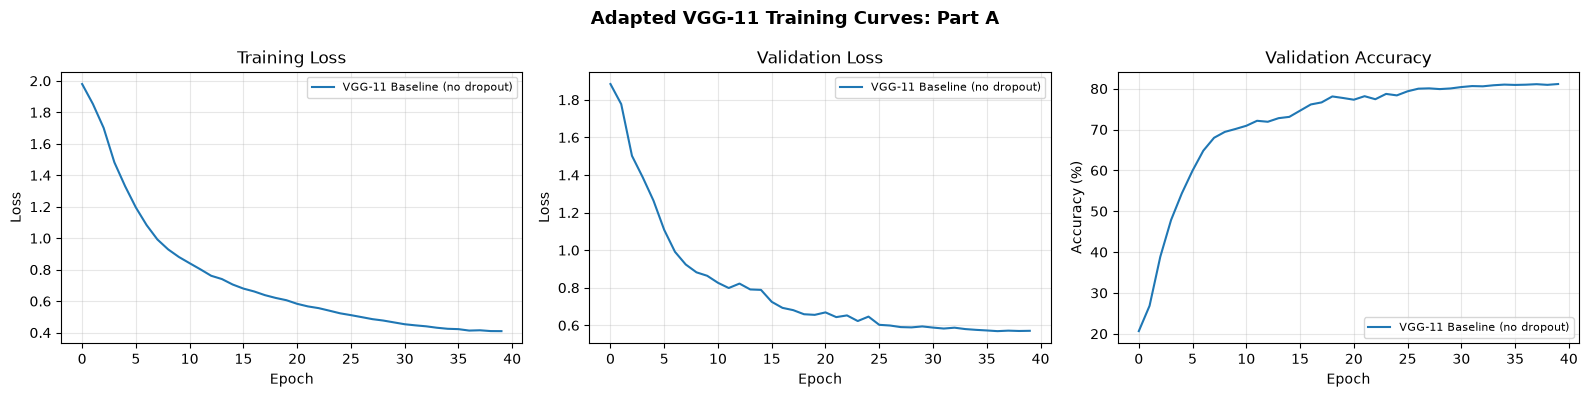

  Saved → output/q2/2a_training_curves.png


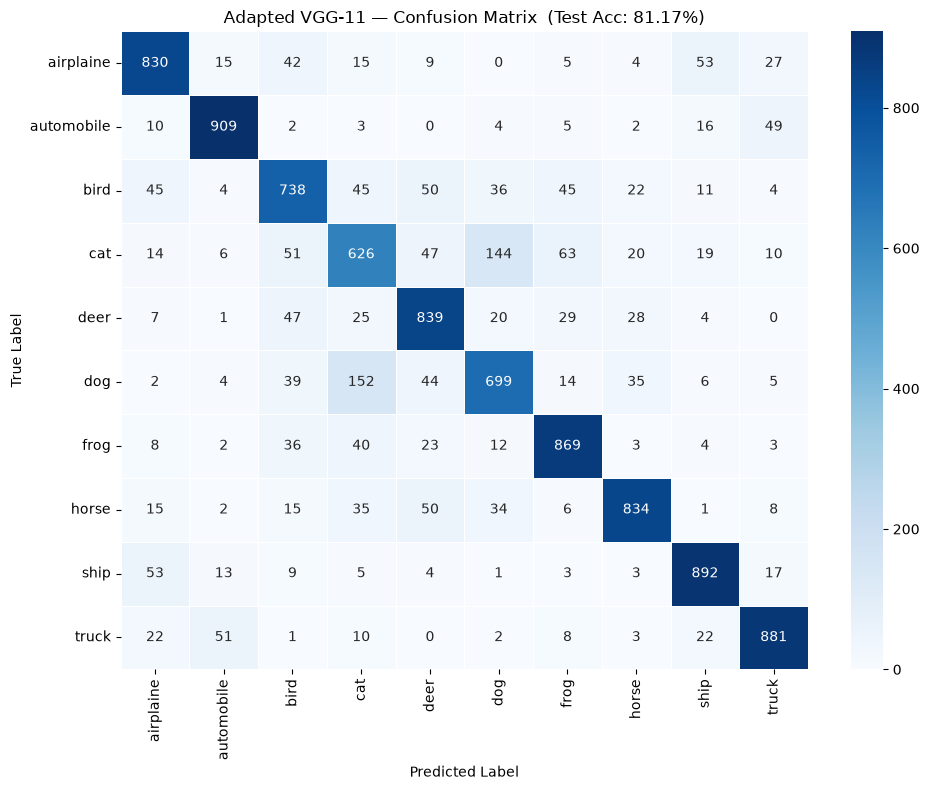

  Saved → output/q2/2a_confusion_matrix.png

AlexNet vs VGG-11 Comparison
  Metric                                   AlexNet       VGG-11
  ────────────────────────────────────────────────────────────
  Parameters                               973,322      974,186
  Test Accuracy (%)                          85.50        81.17

Question 2: Part B

VGG-11 Dropout rate p = 0.3
  Ep   1/40  TrLoss 2.0157  VlLoss 1.9041  VlAcc  20.76%  (3.7s)
  Ep   2/40  TrLoss 1.8476  VlLoss 1.7389  VlAcc  27.52%  (3.9s)
  Ep   3/40  TrLoss 1.6486  VlLoss 1.4615  VlAcc  43.34%  (4.0s)
  Ep   4/40  TrLoss 1.4545  VlLoss 1.3344  VlAcc  49.28%  (3.6s)
  Ep   5/40  TrLoss 1.3179  VlLoss 1.1781  VlAcc  57.40%  (3.6s)
  Ep   6/40  TrLoss 1.1835  VlLoss 1.1002  VlAcc  60.16%  (3.5s)
  Ep   7/40  TrLoss 1.0749  VlLoss 1.0076  VlAcc  64.36%  (3.8s)
  Ep   8/40  TrLoss 1.0072  VlLoss 0.9162  VlAcc  67.64%  (3.9s)
  Ep   9/40  TrLoss 0.9447  VlLoss 0.8585  VlAcc  70.00%  (4.0s)
  Ep  10/40  TrLoss 0.8874  VlLoss 0.

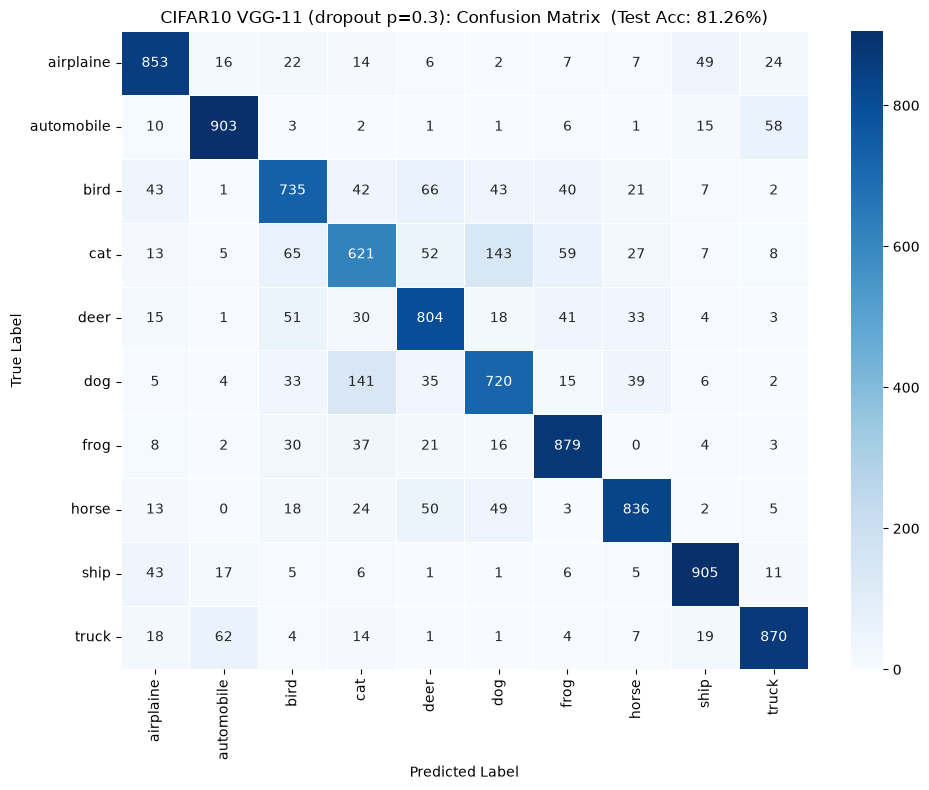

  Saved → output/q2/2b_cm_p03.png

VGG-11 Dropout rate p = 0.5
  Ep   1/40  TrLoss 2.0050  VlLoss 1.8510  VlAcc  20.92%  (3.9s)
  Ep   2/40  TrLoss 1.8582  VlLoss 1.7729  VlAcc  27.02%  (3.8s)
  Ep   3/40  TrLoss 1.6976  VlLoss 1.5355  VlAcc  38.10%  (3.9s)
  Ep   4/40  TrLoss 1.4937  VlLoss 1.3410  VlAcc  50.20%  (3.9s)
  Ep   5/40  TrLoss 1.3447  VlLoss 1.2393  VlAcc  55.58%  (3.8s)
  Ep   6/40  TrLoss 1.2380  VlLoss 1.1376  VlAcc  59.54%  (3.8s)
  Ep   7/40  TrLoss 1.1488  VlLoss 1.0654  VlAcc  60.76%  (3.9s)
  Ep   8/40  TrLoss 1.0740  VlLoss 0.9757  VlAcc  65.58%  (3.8s)
  Ep   9/40  TrLoss 1.0032  VlLoss 0.9063  VlAcc  68.20%  (3.8s)
  Ep  10/40  TrLoss 0.9498  VlLoss 0.8916  VlAcc  68.94%  (3.8s)
  Ep  11/40  TrLoss 0.9098  VlLoss 0.8686  VlAcc  69.74%  (3.8s)
  Ep  12/40  TrLoss 0.8745  VlLoss 0.8571  VlAcc  69.78%  (3.9s)
  Ep  13/40  TrLoss 0.8361  VlLoss 0.8549  VlAcc  70.40%  (3.9s)
  Ep  14/40  TrLoss 0.8100  VlLoss 0.7723  VlAcc  73.88%  (3.8s)
  Ep  15/40  TrLoss 0.7797 

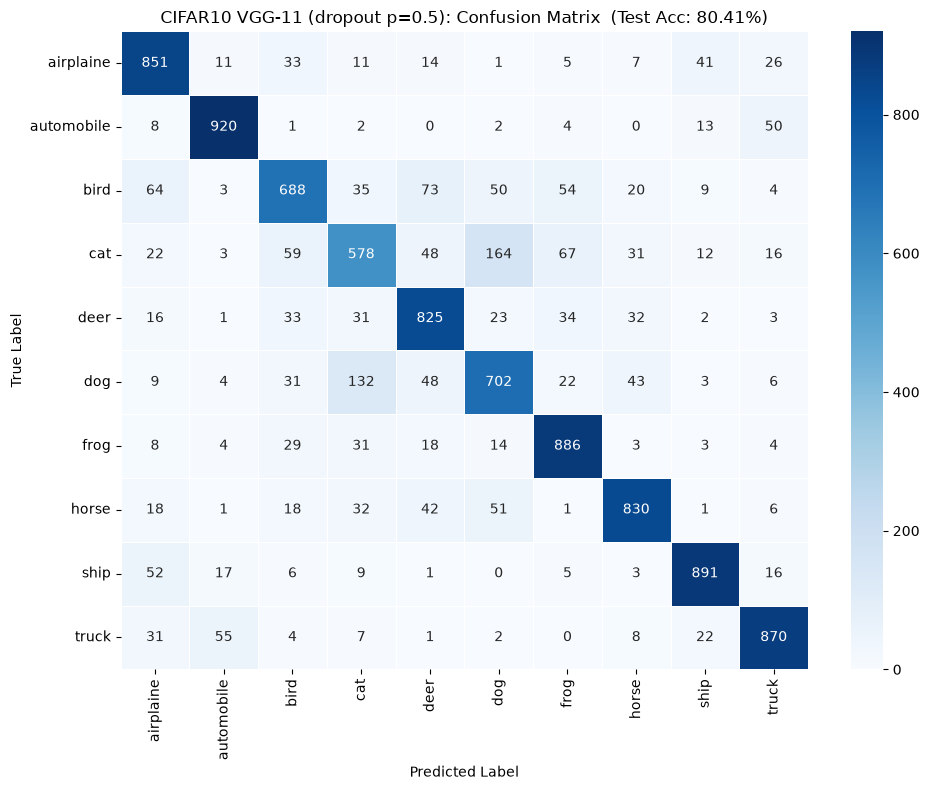

  Saved → output/q2/2b_cm_p05.png


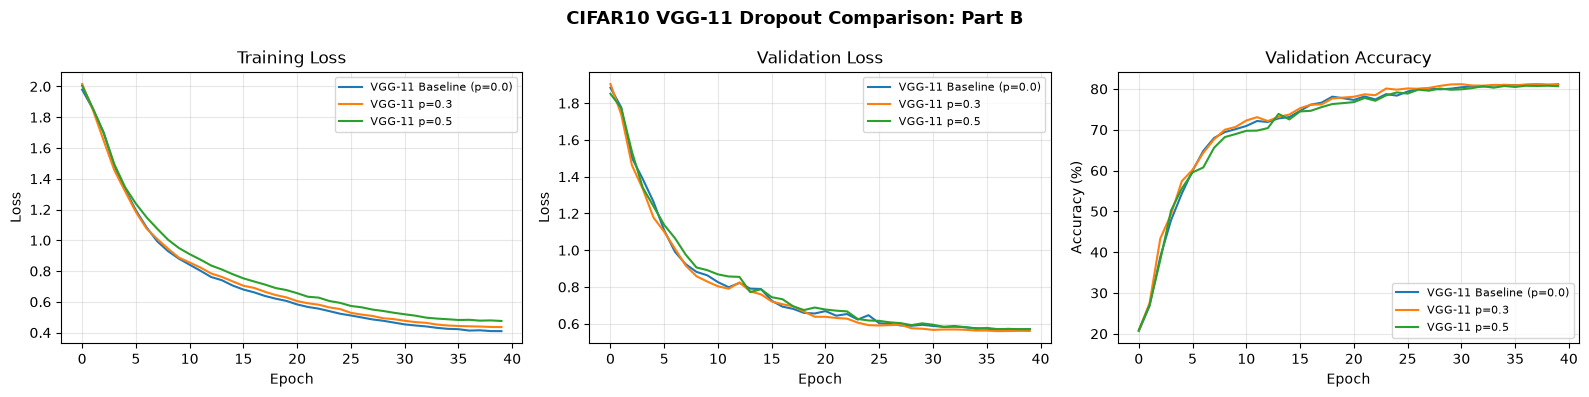

  Saved → output/q2/2b_dropout_comparison.png

VGG-11 Train/Val Gap Analysis 
  Variant                       TrLoss     VlLoss        Gap    VlAcc
  ─────────────────────────────────────────────────────────────────
  VGG-11 Baseline (p=0.0)       0.4094     0.5709    -0.1615   81.14%
  VGG-11 p=0.3                  0.4356     0.5609    -0.1253   81.04%
  VGG-11 p=0.5                  0.4755     0.5706    -0.0951   80.68%

Cross-Model Dropout Summary
  Variant                    Test Acc (%)
  ────────────────────────────────────────
  AlexNet p=0.0                     85.50
  AlexNet p=0.3                     84.87
  AlexNet p=0.5                     85.06
  VGG-11 p=0.0                      81.17
  VGG-11 p=0.3                      81.26
  VGG-11 p=0.5                      80.41

Question 2  Summary
  VGG-11 p=0.0             : 81.17%
  VGG-11 p=0.3             : 81.26% ◄ best
  VGG-11 p=0.5             : 80.41%
  Saved → output/q2/results.json


In [ ]:
def main():
    print("=" * 60)
    print("Question 2: ADAPTED VGG-11 ON CIFAR-10")
    print(f"Random seed : {SEED}")
    print("=" * 60)

    # Load Problem 1 results (if available)
    p1_results = load_results("output/q1")
    if p1_results:
        print(f"\nLoaded Problem 1 results  "
              f"(AlexNet baseline acc: {p1_results.get('baseline_acc', '?'):.2f}%)")
    else:
        print("\nNo Problem 1 results found — run problem1_alexnet.py first "
              "for the cross-architecture comparison.")

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    set_seed(SEED)
    train_split, val_split, test_split = get_split(BATCH_SIZE)

    # Executing Part A
    model_a, hist_a, acc_a, params_a, avg_time_a, conv_ep_a = part_a(
        train_split, val_split, test_split, device, p1_results
    )

    # Executing Part B
    vgg_dropout = part_b(
        hist_a, acc_a,
        train_split, val_split, test_split, device,
        p1_results,
    )

    # Summary
    print("\n" + "=" * 60)
    print("Question 2  Summary")
    print("=" * 60)
    best_acc = max(vgg_dropout.values())
    for variant, acc in vgg_dropout.items():
        marker = " ◄ best" if acc == best_acc else ""
        print(f"  VGG-11 {variant:<18}: {acc:.2f}%{marker}")

    # Saving Results for Problem 3
    save_results(out_path, {
        "seed"            : SEED,
        "epochs"          : NUM_EPOCHS,
        "batch_size"      : BATCH_SIZE,
        "lr"              : learning_rate,
        "weight_decay"    : weight_decay,
        "optimizer"       : "Adam",
        "scheduler"       : "CosineAnnealingLR",
        "params"          : params_a,
        "baseline_acc"    : acc_a,
        "dropout_03_acc"  : vgg_dropout.get("p=0.3", 0.0),
        "dropout_05_acc"  : vgg_dropout.get("p=0.5", 0.0),
        "best_acc"        : best_acc,
        "avg_epoch_time"  : avg_time_a,
        "convergence_epoch": conv_ep_a,
    })

    return {
        "model"          : model_a,
        "history"        : hist_a,
        "baseline_acc"   : acc_a,
        "params"         : params_a,
        "dropout_results": vgg_dropout,
        "best_acc"       : best_acc,
    }


if __name__ == "__main__":
    main()